In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

In [ ]:
# Load the California housing dataset as a pandas DataFrame
housing_dataset = fetch_california_housing(as_frame=True)
df = housing_dataset.frame.copy()
# Check the number of rows and columns
print("Shape of the dataset: ", df.shape)

Shape of the dataset:  (20640, 9)


In [ ]:
# Inspect column names, data types, and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
# Review summary statistics for all numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


## Initial Observation

Before applying outlier rules, compare the quartiles with the maximum value.

For the `Population` column:

- 75th percentile: `1725`
- Maximum value: `35682`

The large gap between the 75th percentile and the maximum value suggests a right-skewed distribution with possible high-end outliers.


## Column Selected for Outlier Analysis

The `Population` column is selected because its summary statistics show a strong difference between the typical values and the maximum value.


## Method 1: KDE Plot and Box Plot

Visual methods are useful as the first step in outlier detection.

- KDE plot shows the distribution shape.
- Box plot shows values that are far away from the central range.


In [ ]:
col = "Population"
df[col].head()

0     322.0
1    2401.0
2     496.0
3     558.0
4     565.0
Name: Population, dtype: float64

<Axes: xlabel='Population', ylabel='Density'>

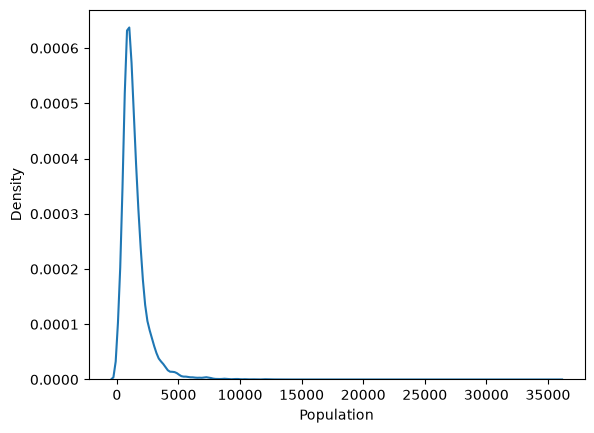

In [ ]:
# Plot the density curve to inspect the distribution shape
sns.kdeplot(df[col])
# Observation: Population is right-skewed, with most values at the lower end and a few very large values.

<Axes: ylabel='Population'>

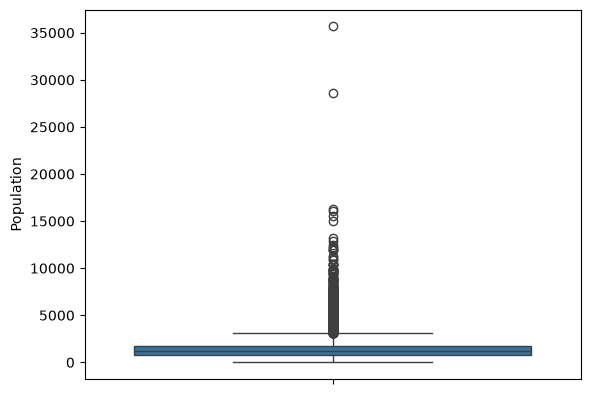

In [ ]:
# Use a box plot to visually detect values far from the central range
sns.boxplot(df[col])
# Observation: Points beyond the upper whisker are potential high-end outliers.

### Visual Observation

The `Population` distribution is strongly right-skewed. Most values are concentrated at the lower end, while a small number of observations extend far to the right.

The box plot also shows many points above the upper whisker, confirming possible high-end outliers.


## Method 2: IQR (Interquartile Range)

The IQR method uses the middle 50% of the data to calculate lower and upper boundaries.

Formula:

- `IQR = Q3 - Q1`
- `Lower Bound = Q1 - 1.5 * IQR`
- `Upper Bound = Q3 + 1.5 * IQR`

Values outside these boundaries are treated as potential outliers.


In [ ]:
# Create IQR boundaries. Values below the lower bound or above the upper bound are potential outliers.


def get_iqr_lower_upper_bound(data: pd.Series, factor=1.5):
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - factor * iqr
    upper_bound = q3 + factor * iqr
    return lower_bound, upper_bound

In [ ]:
# Calculate IQR boundaries for the Population column
lower_bound, upper_bound = get_iqr_lower_upper_bound(df[col])
print(lower_bound, upper_bound)

-620.0 3132.0


### IQR Boundary Observation

The IQR lower bound is `-620`, which is not meaningful for population because population cannot be negative.

The upper bound is `3132`, so values greater than `3132` are considered IQR-based outliers for this column.


In [ ]:
# Since population cannot be negative, only the upper IQR boundary is used for the outlier mask.
iqr_outlier_mask = df[col] > upper_bound
iqr_outlier_mask.head()

0    False
1    False
2    False
3    False
4    False
Name: Population, dtype: bool

In [ ]:
# Count IQR outliers and calculate their percentage in the dataset
print("Number of outliers: ", iqr_outlier_mask.sum())
print("Percentage of outliers: ", iqr_outlier_mask.mean() * 100)

Number of outliers:  1196
Percentage of outliers:  5.794573643410852


In [ ]:
# Display the Population values flagged as IQR outliers, sorted from highest to lowest
df.loc[iqr_outlier_mask, col].sort_values(ascending=False)

15360    35682.0
9880     28566.0
13139    16305.0
10309    16122.0
6057     15507.0
          ...   
12231     3136.0
5329      3136.0
12454     3134.0
3419      3134.0
15883     3134.0
Name: Population, Length: 1196, dtype: float64

### IQR Result Observation

Using the IQR rule, `1196` rows are flagged as outliers, which is about `5.79%` of the dataset.

These are not automatically wrong values. They are high-population observations that should be reviewed before deciding whether to cap, transform, remove, or keep them.


## Method 3: Z-Score

The z-score method flags values that are far from the mean.

A common rule is to mark values as outliers when they are more than `3` standard deviations away from the mean.


In [ ]:
def detect_outliers_zscore(data: pd.Series):
    mean = data.mean()
    std = data.std()
    lower_bound = mean - 3 * std
    upper_bound = mean + 3 * std

    zscore_outlier_mask = (data < lower_bound) | (data > upper_bound)
    return zscore_outlier_mask

In [ ]:
z_score_outlier_mask = detect_outliers_zscore(df[col])

print("Number of outliers: ", z_score_outlier_mask.sum())
print("Percentage of outliers: ", z_score_outlier_mask.mean() * 100)

Number of outliers:  342
Percentage of outliers:  1.6569767441860463


### Z-Score Result Observation

Using the z-score rule with a `3` standard deviation threshold, `342` rows are flagged as outliers, which is about `1.66%` of the dataset.

This method is more conservative than IQR here because the large extreme values increase the mean and standard deviation.


## Comparing IQR and Z-Score

This comparison table shows whether each `Population` value is marked as an outlier by the IQR method, the z-score method, or both.


In [ ]:
comparison = pd.DataFrame(
    {
        "value": df[col],
        "iqr_outlier": iqr_outlier_mask,
        "zscore_outlier": z_score_outlier_mask,
    }
)
comparison.head()
# Compare whether each value is flagged as an outlier by IQR and z-score methods.

,value,iqr_outlier,zscore_outlier
0,322.0,False,False
1,2401.0,False,False
2,496.0,False,False
3,558.0,False,False
4,565.0,False,False


## Final Conclusion

For the `Population` column:

- The distribution is right-skewed.
- The IQR method detects more potential outliers than the z-score method.
- The z-score method is less ideal here because it works best when the data is closer to normally distributed.
- Since population values cannot be negative, lower-bound outliers are not relevant in this case.
- High population values may be valid observations, so they should not be removed blindly.

A practical next step is to keep the values for analysis, or apply capping/log transformation if the selected machine learning model is sensitive to extreme values.


In [ ]:
comparison[["iqr_outlier", "zscore_outlier"]].sum()

iqr_outlier       1196
zscore_outlier     342
dtype: int64